# 🫀 Heart Attack Risk Prediction
### CDC BRFSS 2022 Dataset — Habiba's ML Final Project 2026

**Student:** Habiba Mohamed Hassan · **ID:** 2210019322

This notebook builds a leak-safe machine-learning pipeline that estimates the risk of
having had a heart attack from 18 self-reported health indicators (CDC BRFSS 2022).

**Goal:** Predict `HadHeartAttack` (Yes / No)  
**Dataset:** ~445,000 respondents, 40 raw indicators (we keep 18 + target)  
**Approach:** Clean → Explore → Encode → Pipeline → Compare 4 models → Tune threshold → Save 🌸

---

## 🔧 Step 1: Setup & Imports
All the libraries we need, plus the warm color palette I'll reuse across every plot.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = 'HadHeartAttack'

# 🌸 Habiba's warm palette (color-blind friendly).
NEG_COLOR = '#26A69A'   # teal     -> No Heart Attack
POS_COLOR = '#C2185B'   # rose     -> Heart Attack
ACCENT    = '#7B1FA2'   # purple   -> ROC accent
WARM      = '#FF8A65'   # coral    -> warm secondary
AMBER     = '#FFB300'   # amber    -> threshold marker
EDGE      = '#3a1a2c'   # plum-ink -> bar edges
METRIC_PALETTE = ['#C2185B', '#7B1FA2', '#FF8A65', '#FFB300', '#26A69A']

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 60)

DATA_PATH = Path('data') / 'heart.csv'
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
print('🌸 All libraries loaded successfully!')
print('📁 figures/ folder ready')

🌸 All libraries loaded successfully!
📁 figures/ folder ready


## 📂 Step 2: Load the dataset

In [2]:
data = pd.read_csv(DATA_PATH)
print(f'✅ Dataset loaded: {data.shape[0]:,} rows × {data.shape[1]} columns')
data.head()

✅ Dataset loaded: 445,132 rows × 40 columns


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,BlindOrVisionDifficulty,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AgeCategory,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,No,No,No,No,No,No,No,No,Yes,No,No,No,No,No,No,Never smoked,Not at all (right now),No,"White only, Non-Hispanic",Age 80 or older,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 80 or older,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",Age 55 to 59,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,No,No,Yes,No,No,No,No,Yes,No,No,No,No,No,No,No,Current smoker - now smokes some days,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",NaN,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Never smoked,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",Age 40 to 44,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [3]:
# Quick look at column types
print('Data types:')
print(data.dtypes.value_counts())

Data types:
object     34
float64     6
Name: count, dtype: int64


## 🔍 Step 3: Check missing values
Real-world health data is messy — let's see what we're dealing with before we touch anything.

In [4]:
missing = data.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(f'Columns with missing values: {len(missing)}')
print(missing.head(15))

Columns with missing values: 38
TetanusLast10Tdap          82516
PneumoVaxEver              77040
HIVTesting                 66127
ChestScan                  56046
CovidPos                   50764
HighRiskLastYear           50623
BMI                        48806
FluVaxLast12               47121
AlcoholDrinkers            46574
WeightInKilograms          42078
ECigaretteUsage            35660
SmokerStatus               35462
HeightInMeters             28652
DifficultyErrands          25656
DifficultyConcentrating    24240
dtype: int64


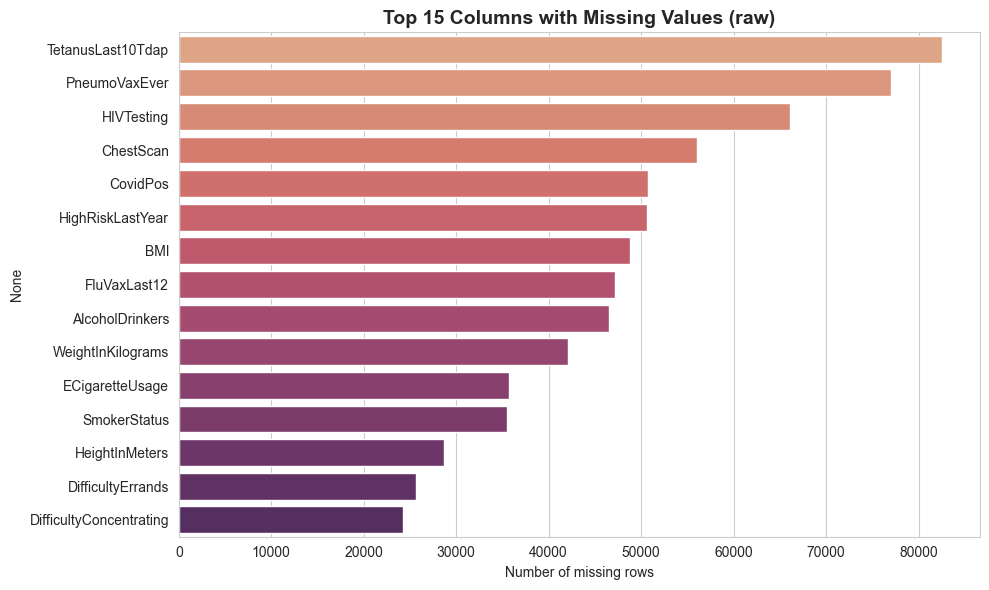

In [5]:
# Visualise the top 15 columns with missing values
plt.figure(figsize=(10, 6))
top_missing = missing.head(15)
sns.barplot(
    x=top_missing.values, y=top_missing.index,
    hue=top_missing.index, palette='flare', legend=False,
)
plt.title('Top 15 Columns with Missing Values (raw)', fontsize=14)
plt.xlabel('Number of missing rows')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_missing_values.png', dpi=120, bbox_inches='tight')
plt.show()

## 🧹 Step 4: Clean the data
Plan:
1. **Keep** the 18 features that matter most for heart-attack risk plus the target.
2. **Drop** rows with any missing values across those columns (we have plenty of data).
3. **Encode** later, *inside* the pipeline so we never leak test-set statistics into training.

In [6]:
keep_cols = [
    'Sex', 'AgeCategory', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays',
    'SleepHours', 'BMI', 'PhysicalActivities', 'SmokerStatus', 'AlcoholDrinkers',
    'HadAngina', 'HadStroke', 'HadDiabetes', 'HadCOPD', 'HadKidneyDisease',
    'HadArthritis', 'DifficultyWalking', 'ChestScan', TARGET,
]
data = data[keep_cols].copy()
before = len(data)
data = data.dropna().reset_index(drop=True)
print(f'🗑️ Dropped {before - len(data):,} rows with missing values')
print(f'📊 Final dataset: {len(data):,} rows × {data.shape[1]} columns')

🗑️ Dropped 117,085 rows with missing values
📊 Final dataset: 328,047 rows × 19 columns


## 📊 Step 5: Explore the data (EDA)
Let's see what story the data tells before we model anything.

In [7]:
target_counts = data[TARGET].value_counts()
print(target_counts)
print(f'\nPositive (had heart attack) rate: {(target_counts["Yes"] / len(data) * 100):.2f}%')

HadHeartAttack
No     310482
Yes     17565
Name: count, dtype: int64

Positive (had heart attack) rate: 5.35%


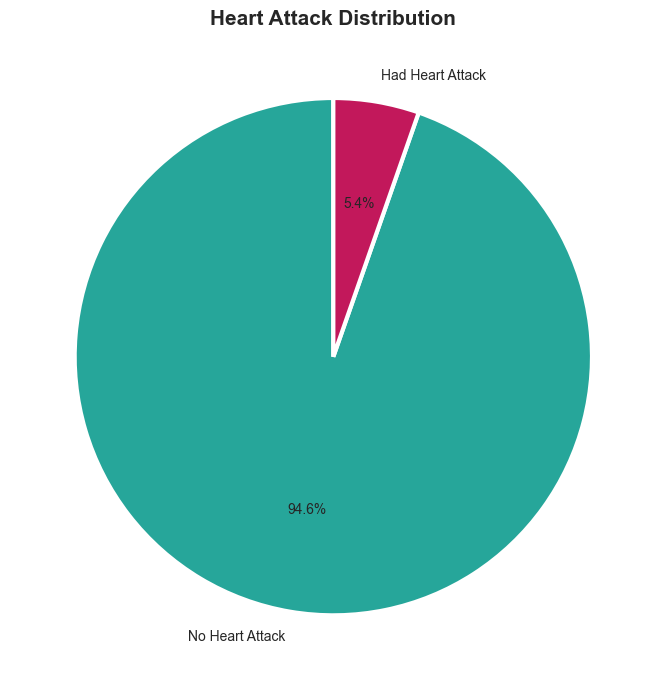

In [8]:
# 02 - Pie chart of the target
plt.figure(figsize=(7, 7))
plt.pie(
    target_counts, labels=['No Heart Attack', 'Had Heart Attack'],
    autopct='%1.1f%%', colors=[NEG_COLOR, POS_COLOR], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3},
)
plt.title('Heart Attack Distribution', fontsize=15)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_target_pie.png', dpi=120, bbox_inches='tight')
plt.show()

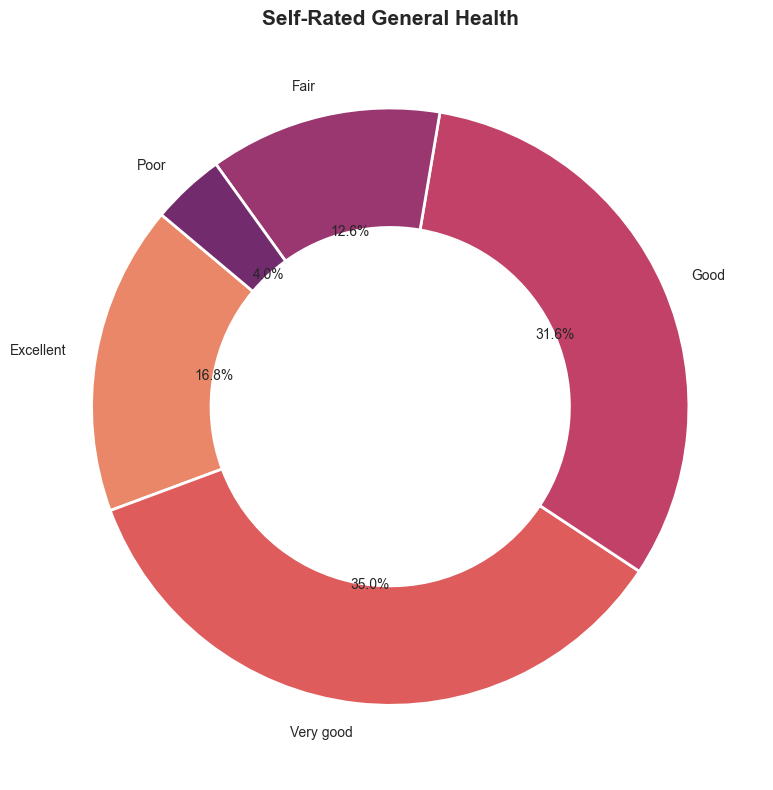

In [9]:
# 03 - Donut chart of General Health
gen_counts = data['GeneralHealth'].value_counts().reindex(
    ['Excellent', 'Very good', 'Good', 'Fair', 'Poor']
)
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    gen_counts, labels=gen_counts.index, autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('flare', len(gen_counts)),
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2},
)
ax.set_title('Self-Rated General Health', fontsize=15)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_general_health_donut.png', dpi=120, bbox_inches='tight')
plt.show()

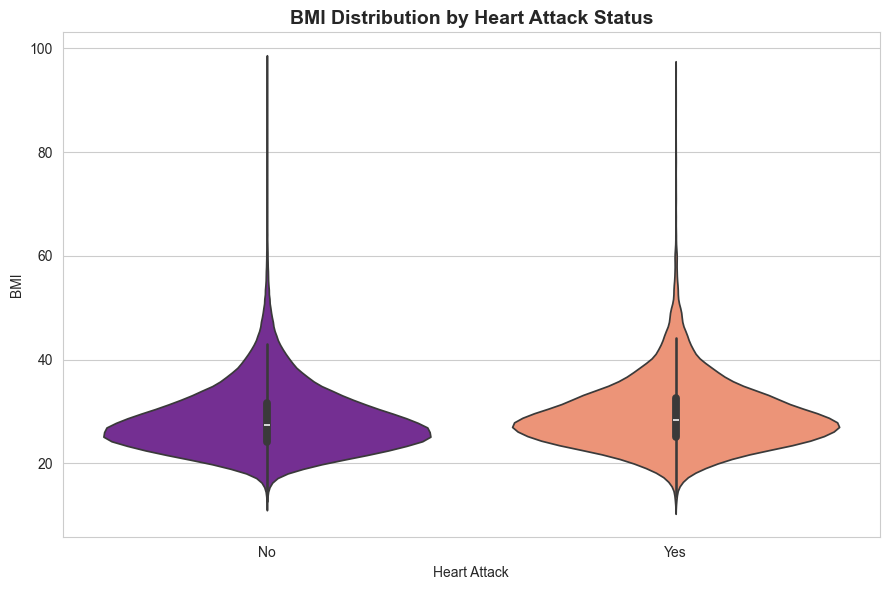

In [10]:
# 04 - BMI violin by target
plt.figure(figsize=(9, 6))
sns.violinplot(
    x=TARGET, y='BMI', data=data,
    hue=TARGET, palette=[ACCENT, WARM], legend=False,
)
plt.title('BMI Distribution by Heart Attack Status', fontsize=14)
plt.xlabel('Heart Attack')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_bmi_violin.png', dpi=120, bbox_inches='tight')
plt.show()

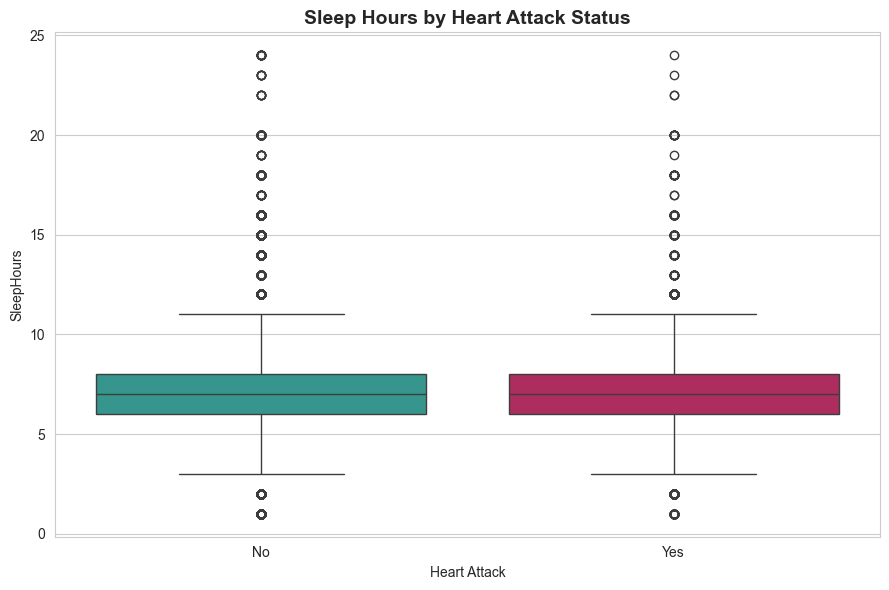

In [11]:
# 05 - Sleep box by target
plt.figure(figsize=(9, 6))
sns.boxplot(
    x=TARGET, y='SleepHours', data=data,
    hue=TARGET, palette=[NEG_COLOR, POS_COLOR], legend=False,
)
plt.title('Sleep Hours by Heart Attack Status', fontsize=14)
plt.xlabel('Heart Attack')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_sleep_box.png', dpi=120, bbox_inches='tight')
plt.show()

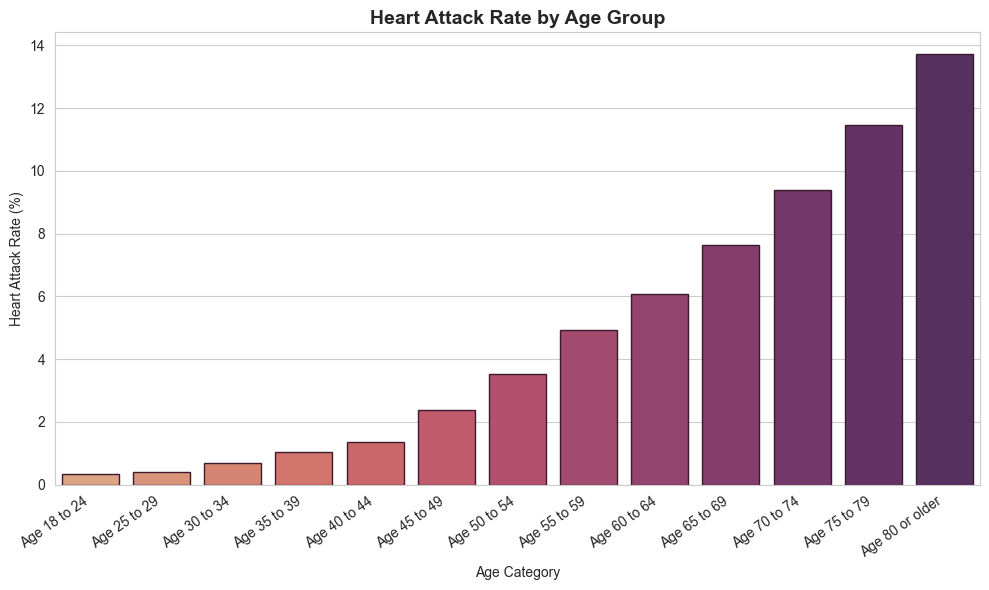

In [12]:
# 06 - Heart attack rate by age group
age_order = [
    'Age 18 to 24', 'Age 25 to 29', 'Age 30 to 34', 'Age 35 to 39',
    'Age 40 to 44', 'Age 45 to 49', 'Age 50 to 54', 'Age 55 to 59',
    'Age 60 to 64', 'Age 65 to 69', 'Age 70 to 74', 'Age 75 to 79',
    'Age 80 or older',
]
age_rate = (
    data.groupby('AgeCategory', observed=False)[TARGET]
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reindex(age_order)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=age_rate.index, y=age_rate.values,
    hue=age_rate.index,
    palette=sns.color_palette('flare', len(age_rate)),
    legend=False, edgecolor=EDGE,
)
plt.title('Heart Attack Rate by Age Group', fontsize=14)
plt.xlabel('Age Category')
plt.ylabel('Heart Attack Rate (%)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_age_vs_heart.png', dpi=120, bbox_inches='tight')
plt.show()

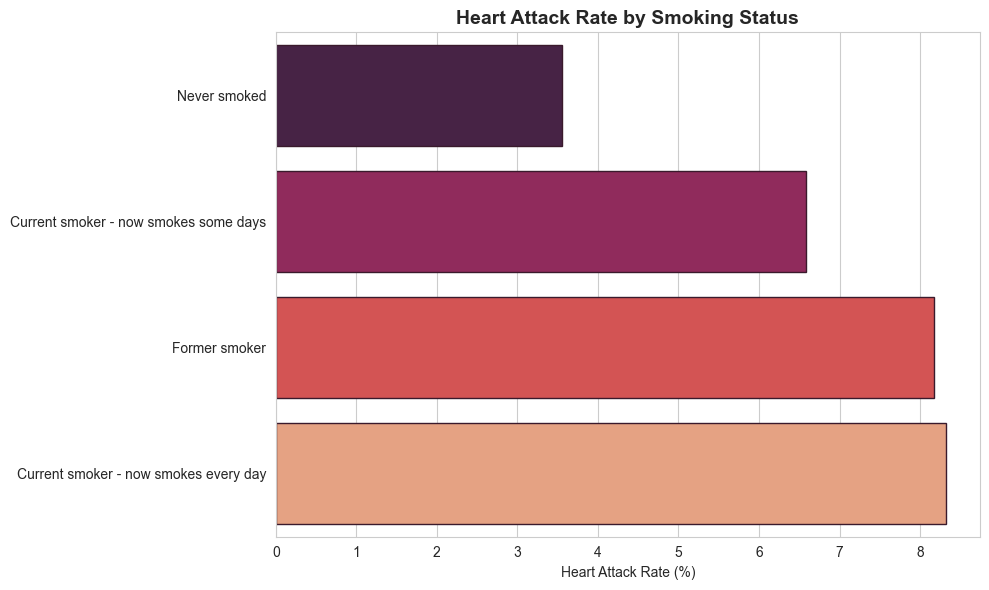

In [13]:
# 07 - Smoking status vs heart attack
smoke_rate = (
    data.groupby('SmokerStatus')[TARGET]
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .sort_values()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=smoke_rate.values, y=smoke_rate.index,
    hue=smoke_rate.index,
    palette=sns.color_palette('rocket', len(smoke_rate)),
    legend=False, edgecolor=EDGE,
)
plt.title('Heart Attack Rate by Smoking Status', fontsize=14)
plt.xlabel('Heart Attack Rate (%)')
plt.ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_smoking_vs_heart.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔢 Step 6: Encode categorical variables
Models eat numbers, not text. Most of these have a natural order (age, general health,
smoking severity, diabetes), so an ordinal encoding keeps the signal compact.

In [14]:
AGE_ORDER = age_order
AGE_MAP = {age: i for i, age in enumerate(AGE_ORDER)}
GEN_MAP = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very good': 3, 'Excellent': 4}
SMOKE_MAP = {
    'Never smoked': 0,
    'Former smoker': 1,
    'Current smoker - now smokes some days': 2,
    'Current smoker - now smokes every day': 3,
}
DIABETES_MAP = {
    'No': 0,
    'No, pre-diabetes or borderline diabetes': 1,
    'Yes, but only during pregnancy (female)': 1,
    'Yes': 2,
}

data['Sex']            = (data['Sex'] == 'Male').astype(int)
data['AgeCategory']    = data['AgeCategory'].map(AGE_MAP).astype(int)
data['GeneralHealth']  = data['GeneralHealth'].map(GEN_MAP).astype(int)
data['SmokerStatus']   = data['SmokerStatus'].map(SMOKE_MAP).astype(int)
data['HadDiabetes']    = data['HadDiabetes'].map(DIABETES_MAP).astype(int)

yes_no_cols = [
    'PhysicalActivities', 'AlcoholDrinkers',
    'HadAngina', 'HadStroke', 'HadCOPD', 'HadKidneyDisease',
    'HadArthritis', 'DifficultyWalking', 'ChestScan',
]
for c in yes_no_cols:
    data[c] = (data[c] == 'Yes').astype(int)

data[TARGET] = (data[TARGET] == 'Yes').astype(int)
print('✅ Encoded all categorical columns')
data.head()

✅ Encoded all categorical columns


,Sex,AgeCategory,GeneralHealth,PhysicalHealthDays,MentalHealthDays,SleepHours,BMI,PhysicalActivities,SmokerStatus,AlcoholDrinkers,HadAngina,HadStroke,HadDiabetes,HadCOPD,HadKidneyDisease,HadArthritis,DifficultyWalking,ChestScan,HadHeartAttack
0,0,12,4,0.0,0.0,6.0,26.57,0,0,0,0,0,0,0,0,0,0,0,0
1,0,7,3,2.0,3.0,5.0,25.61,1,0,0,0,0,0,0,0,0,0,0,0
2,0,4,1,2.0,0.0,9.0,21.77,1,0,1,0,0,0,0,0,0,0,1,0
3,1,12,0,1.0,0.0,7.0,26.08,0,0,0,0,1,2,0,0,0,0,0,1
4,0,12,3,0.0,0.0,7.0,22.96,1,1,1,0,0,0,0,0,0,0,0,0


## 🎯 Step 7: Define features and target
Numeric features (including the ordinal indices) get scaled inside the pipeline.
Binary features pass through untouched.

In [15]:
NUMERIC_FEATURES = [
    'AgeCategory', 'GeneralHealth', 'SmokerStatus', 'HadDiabetes',
    'PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'BMI',
]
BINARY_FEATURES = [
    'Sex', 'PhysicalActivities', 'AlcoholDrinkers',
    'HadAngina', 'HadStroke', 'HadCOPD', 'HadKidneyDisease',
    'HadArthritis', 'DifficultyWalking', 'ChestScan',
]
FEATURE_COLUMNS = NUMERIC_FEATURES + BINARY_FEATURES

X = data[FEATURE_COLUMNS]
y = data[TARGET]
print(f'Features: {X.shape}')
print(f'Target  : {y.shape}')
print(f'Numeric : {len(NUMERIC_FEATURES)} | Binary: {len(BINARY_FEATURES)}')

Features: (328047, 18)
Target  : (328047,)
Numeric : 8 | Binary: 10


## ✂️ Step 8: Train / Test split
Stratified 80/20 so the rare positive class is preserved in both splits.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)
print(f'Training set: {X_train.shape}')
print(f'Testing set : {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.4f}')
print(f'Test  positive rate: {y_test.mean():.4f}')

Training set: (262437, 18)
Testing set : (65610, 18)
Train positive rate: 0.0535
Test  positive rate: 0.0535


## 🏗️ Step 9: Build the leak-safe pipeline
All scaling happens *inside* a `Pipeline`, fit only on the training fold. Whatever we save
to disk is the entire pipeline — so the Flask app does the exact same transformations.

In [17]:
def build_pipeline(estimator):
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    binary_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
    ])
    preprocessor = ColumnTransformer([
        ('num', numeric_pipe, NUMERIC_FEATURES),
        ('bin', binary_pipe, BINARY_FEATURES),
    ])
    return Pipeline([
        ('preprocess', preprocessor),
        ('model', estimator),
    ])

## 🤖 Step 10: Train and compare four models
Heart-attack data is heavily imbalanced (~5% positives), so:
- the tree-based models use `class_weight='balanced'`,
- XGBoost uses `scale_pos_weight = neg / pos`,
- the selection metric is **ROC-AUC**, which is robust to imbalance.

In [18]:
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
spw = neg / pos
print(f'Scale pos weight for XGBoost: {spw:.2f}')

Scale pos weight for XGBoost: 17.68


In [19]:
candidates = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', random_state=RANDOM_STATE,
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, algorithm='SAMME', random_state=RANDOM_STATE,
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=120, max_depth=4, learning_rate=0.08,
        random_state=RANDOM_STATE,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        scale_pos_weight=spw, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=1, tree_method='hist',
    ),
}

rows = []
fitted = {}
for name, est in candidates.items():
    pipe = build_pipeline(est)
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })
    fitted[name] = pipe
    print(f'{name:<20s} ROC-AUC = {rows[-1]["ROC-AUC"]:.4f}')

results_df = (
    pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
)
results_df.round(4)

Decision Tree        ROC-AUC = 0.8825


AdaBoost             ROC-AUC = 0.8936


Gradient Boosting    ROC-AUC = 0.8969


XGBoost              ROC-AUC = 0.8944


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.9501,0.5784,0.2499,0.3490,0.8969
1,XGBoost,0.8278,0.2078,0.7876,0.3288,0.8944
2,AdaBoost,0.9494,0.5578,0.2693,0.3632,0.8936
3,Decision Tree,0.7932,0.1809,0.8110,0.2958,0.8825


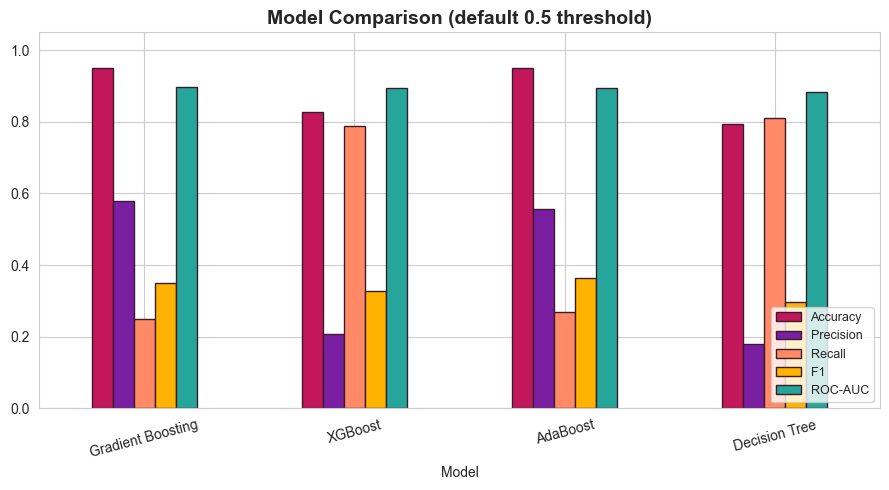

In [20]:
# 08 - Visual comparison of the four models
fig, ax = plt.subplots(figsize=(9, 5))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', color=METRIC_PALETTE, edgecolor=EDGE, ax=ax,
)
ax.set_title('Model Comparison (default 0.5 threshold)', fontsize=14)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=15)
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / '08_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 🏆 Step 11: Pick the best model and tune the threshold
ROC-AUC picks the winner. Then we sweep thresholds 0.10–0.90 in 0.01 steps and choose the
value that maximises **F1** on the test set — much more useful than the default 0.5 cutoff
for an imbalanced screening task.

In [21]:
best_name = results_df.iloc[0]['Model']
best_pipe = fitted[best_name]
proba = best_pipe.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
f1_scores = [f1_score(y_test, (proba >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx])
print(f'🏆 Best model    : {best_name}')
print(f'🎚️ Best threshold: {best_threshold:.2f}')
print(f'⭐ Best F1       : {f1_scores[best_idx]:.4f}')

🏆 Best model    : Gradient Boosting
🎚️ Best threshold: 0.28
⭐ Best F1       : 0.4854


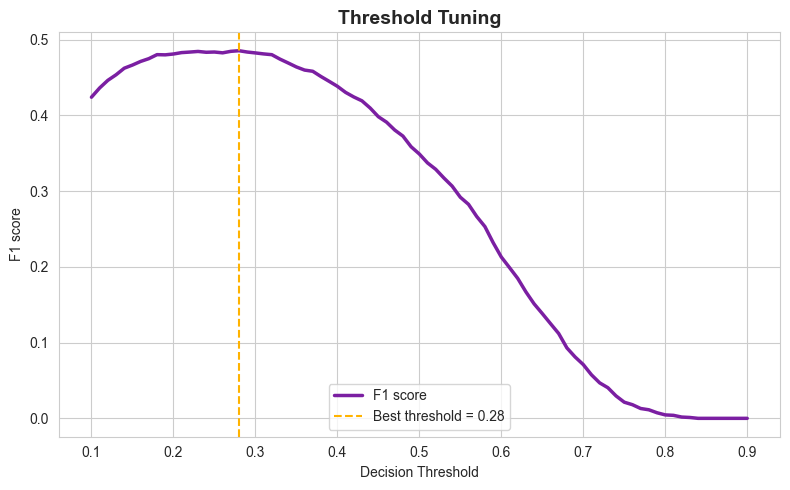

In [22]:
# 11 - Threshold tuning curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, f1_scores, color=ACCENT, lw=2.5, label='F1 score')
ax.axvline(best_threshold, color=AMBER, linestyle='--',
           label=f'Best threshold = {best_threshold:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1 score')
ax.set_title('Threshold Tuning', fontsize=14)
ax.legend(loc='lower center')
fig.tight_layout()
fig.savefig(FIG_DIR / '11_precision_recall.png', dpi=120, bbox_inches='tight')
plt.show()

## 📋 Step 12: Final evaluation

In [23]:
final_pred = (proba >= best_threshold).astype(int)

metrics = {
    'best_model': best_name,
    'best_threshold': best_threshold,
    'accuracy':  float(accuracy_score(y_test, final_pred)),
    'precision': float(precision_score(y_test, final_pred, zero_division=0)),
    'recall':    float(recall_score(y_test, final_pred)),
    'f1':        float(f1_score(y_test, final_pred)),
    'roc_auc':   float(roc_auc_score(y_test, proba)),
}
for k, v in metrics.items():
    print(f'{k:<15s}: {v:.4f}' if isinstance(v, float) else f'{k:<15s}: {v}')

print('\n📋 Classification Report:')
print(classification_report(y_test, final_pred, target_names=['No Heart Attack', 'Heart Attack']))

best_model     : Gradient Boosting
best_threshold : 0.2800
accuracy       : 0.9434
precision      : 0.4727
recall         : 0.4987
f1             : 0.4854
roc_auc        : 0.8969

📋 Classification Report:
                 precision    recall  f1-score   support

No Heart Attack       0.97      0.97      0.97     62097
   Heart Attack       0.47      0.50      0.49      3513

       accuracy                           0.94     65610
      macro avg       0.72      0.73      0.73     65610
   weighted avg       0.94      0.94      0.94     65610



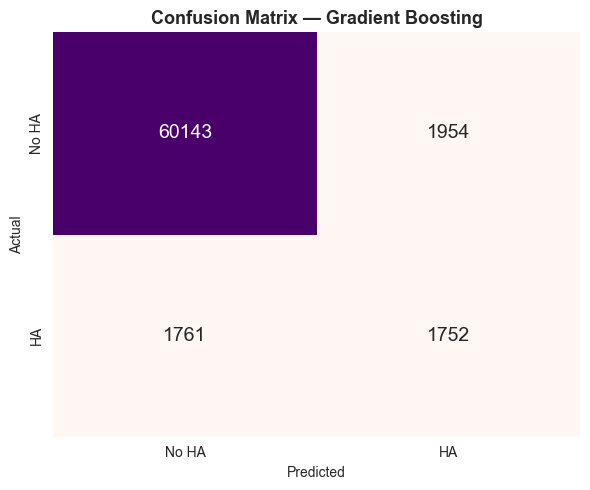

In [24]:
# 09 - Confusion matrix
cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='RdPu', cbar=False,
    annot_kws={'size': 14},
    xticklabels=['No HA', 'HA'], yticklabels=['No HA', 'HA'],
)
plt.title(f'Confusion Matrix — {best_name}', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

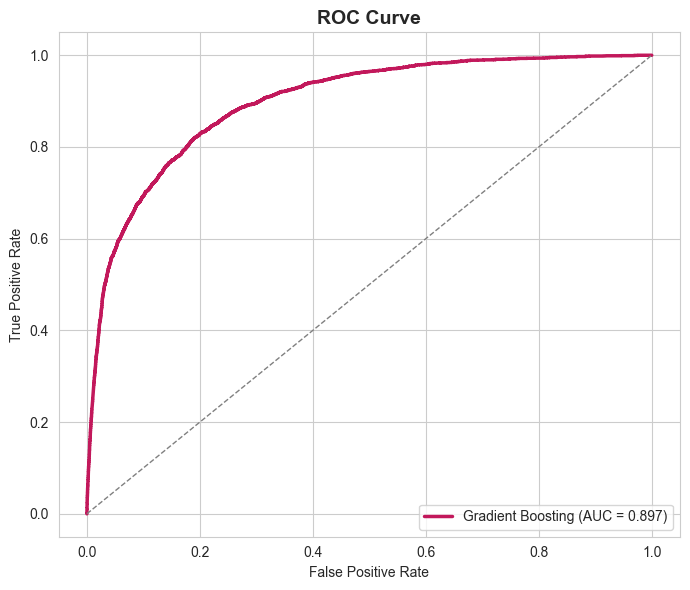

In [25]:
# 10 - ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color=POS_COLOR, lw=2.5,
         label=f'{best_name} (AUC = {metrics["roc_auc"]:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / '10_roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## 💾 Step 13: Save the model and everything the Flask app needs
The pipeline already contains the imputer + scaler + estimator, so the app only needs
**one** model file plus the feature order, the tuned threshold, and a metadata JSON.

In [26]:
joblib.dump(best_pipe, 'heart_model.pkl')
joblib.dump(FEATURE_COLUMNS, 'heart_features.pkl')
joblib.dump(best_threshold, 'heart_threshold.pkl')

metadata = {
    'project': 'Heart Attack Risk Predictor',
    'student': 'Habiba Mohamed Hassan',
    'student_id': '2210019322',
    'dataset': 'CDC BRFSS 2022',
    'rows': int(len(data)),
    'columns': int(len(data.columns)),
    'target': TARGET,
    'positive_class_rows': int(data[TARGET].sum()),
    'negative_class_rows': int((data[TARGET] == 0).sum()),
    'numeric_features': NUMERIC_FEATURES,
    'binary_features': BINARY_FEATURES,
    'feature_columns': FEATURE_COLUMNS,
    'encoders': {
        'AGE_ORDER': AGE_ORDER, 'AGE_MAP': AGE_MAP,
        'GEN_MAP': GEN_MAP, 'SMOKE_MAP': SMOKE_MAP,
        'DIABETES_MAP': DIABETES_MAP,
    },
    'defaults': {
        'BMI': 27.5, 'SleepHours': 7,
        'PhysicalHealthDays': 0, 'MentalHealthDays': 0,
    },
    'model_results': results_df.round(4).to_dict(orient='records'),
    'metrics': metrics,
}
Path('heart_metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print('✅ Saved files:')
for f in ['heart_model.pkl', 'heart_features.pkl', 'heart_threshold.pkl', 'heart_metadata.json']:
    size_kb = os.path.getsize(f) / 1024
    print(f'   • {f}  ({size_kb:.1f} KB)')

✅ Saved files:
   • heart_model.pkl  (403.5 KB)
   • heart_features.pkl  (0.3 KB)
   • heart_threshold.pkl  (0.0 KB)
   • heart_metadata.json  (3.3 KB)


## 🔁 Step 14: Inference demo
Reload the saved pipeline and run a prediction on a synthetic high-risk patient — exactly
the way `app.py` does it at runtime.

In [27]:
loaded_model = joblib.load('heart_model.pkl')
loaded_features = joblib.load('heart_features.pkl')
loaded_threshold = joblib.load('heart_threshold.pkl')

sample_patient = {
    'Sex': 1,
    'AgeCategory': AGE_MAP['Age 70 to 74'],
    'GeneralHealth': GEN_MAP['Poor'],
    'SmokerStatus': SMOKE_MAP['Current smoker - now smokes every day'],
    'HadDiabetes': DIABETES_MAP['Yes'],
    'PhysicalHealthDays': 22,
    'MentalHealthDays': 14,
    'SleepHours': 5,
    'BMI': 33.4,
    'PhysicalActivities': 0,
    'AlcoholDrinkers': 0,
    'HadAngina': 1,
    'HadStroke': 1,
    'HadCOPD': 1,
    'HadKidneyDisease': 1,
    'HadArthritis': 1,
    'DifficultyWalking': 1,
    'ChestScan': 1,
}
row = pd.DataFrame([sample_patient])[loaded_features]
proba_demo = float(loaded_model.predict_proba(row)[0, 1])
label = '⚠️ HIGH risk' if proba_demo >= loaded_threshold else '🛡️ LOW risk'
print(f'Predicted probability: {proba_demo * 100:.2f}%')
print(f'Tuned threshold     : {loaded_threshold * 100:.2f}%')
print(f'Final decision      : {label}')

Predicted probability: 79.69%
Tuned threshold     : 28.00%
Final decision      : ⚠️ HIGH risk


## 🌸 Done!

The model is trained, evaluated, threshold-tuned, and saved. The Flask web app (`app.py`)
loads the same `heart_*.pkl` artefacts and reproduces the exact decision the inference
demo above just made.

— Habiba 💜